# TCRen potential & contact-statistics analysis

Reproduces the core TCRen-manuscript analyses from the committed contact data
(`data/contact_maps_PDB.csv` + `data/summary_PDB_structures.csv`):

- the TCRen potential (re-derived) and its agreement with the published values;
- the Miyazawa-Jernigan and Keskin reference potentials;
- the distribution of TCR-peptide contacts per structure and per TCR region;
- how contacts distribute over peptide and CDR3 positions as a function of length.

In [1]:
# Environment + load the manuscript contact data
%matplotlib inline
import sys, numpy as np, polars as pl, matplotlib.pyplot as plt, tcren
from tcren import analysis as an
from tcren.potential import tcren as load_tcren, mj, keskin, derive_tcren
print('python', sys.version.split()[0], '| polars', pl.__version__, '| tcren', tcren.__version__)

# The manuscript contact map + structure summary are committed as the regression oracle.
CONTACTS = 'tests/assets/oracle/data/contact_maps_PDB.csv'
SUMMARY = 'tests/assets/oracle/data/summary_PDB_structures.csv'
import os
if not os.path.exists(CONTACTS):  # allow running from notebooks/
    CONTACTS, SUMMARY = '../' + CONTACTS, '../' + SUMMARY
df = an.load_interface_contacts(CONTACTS, SUMMARY)
df.select('pdb.id', 'chain.type.from', 'region.type.from', 'residue.aa.from', 'residue.aa.to', 'peptide_pos', 'peptide_len', 'cdr3_len').head()

python 3.11.15 | polars 1.41.2 | tcren 2.1.2


pdb.id,chain.type.from,region.type.from,residue.aa.from,residue.aa.to,peptide_pos,peptide_len,cdr3_len
str,str,str,str,str,i64,u32,u32
"""5m01""","""TRA""","""CDR3""","""Y""","""K""",0,9,12
"""5m01""","""TRA""","""CDR3""","""Y""","""K""",0,9,12
"""5m01""","""TRA""","""CDR3""","""Y""","""A""",1,9,12
"""5m01""","""TRA""","""CDR3""","""Y""","""A""",1,9,12
"""5m01""","""TRA""","""CDR3""","""G""","""A""",3,9,12


In [2]:
# Helper: plot a pairwise potential as a heatmap
def plot_potential(ax, potential, title, cmap='RdBu_r', vlim=None):
    m, froms, tos = an.potential_matrix(potential)
    vlim = vlim or np.nanmax(np.abs(m))
    im = ax.imshow(m, cmap=cmap, vmin=-vlim, vmax=vlim, aspect='equal')
    ax.set_xticks(range(len(tos))); ax.set_xticklabels(tos, fontsize=6)
    ax.set_yticks(range(len(froms))); ax.set_yticklabels(froms, fontsize=6)
    ax.set_xlabel('antigen residue'); ax.set_ylabel('TCR residue'); ax.set_title(title)
    return im

max |derived - published| = 0.0


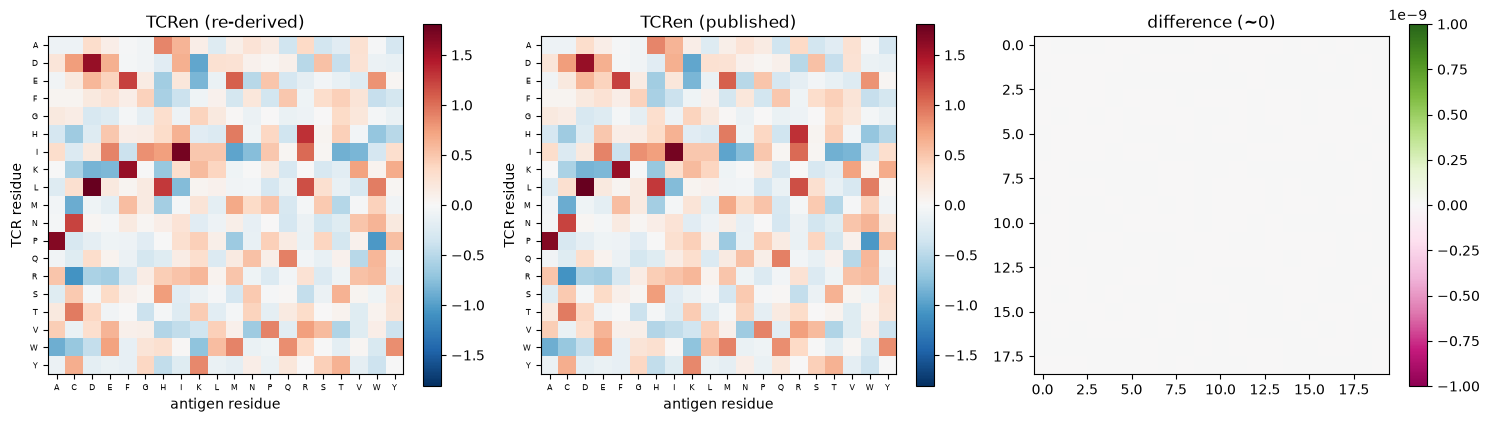

In [3]:
# TCRen potential: re-derived from the non-redundant set, vs the published values, + difference
nonred = pl.read_csv(SUMMARY).filter(pl.col('nonred'))['pdb.id'].to_list()
derived = derive_tcren(pl.read_csv(CONTACTS), include=nonred)
cmp = an.compare_potentials(derived, load_tcren())   # residue-pair diff = derived - published
print('max |derived - published| =', round(cmp['diff'].abs().max(), 12))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = plot_potential(axes[0], derived, 'TCRen (re-derived)')
im1 = plot_potential(axes[1], load_tcren(), 'TCRen (published)')
# difference heatmap straight from the compare_potentials frame (no manual re-join)
froms = sorted(cmp['residue.aa.from'].unique().to_list()); tos = sorted(cmp['residue.aa.to'].unique().to_list())
M = np.full((len(froms), len(tos)), np.nan)
fi = {a: i for i, a in enumerate(froms)}; ti = {a: i for i, a in enumerate(tos)}
for r in cmp.iter_rows(named=True): M[fi[r['residue.aa.from']], ti[r['residue.aa.to']]] = r['diff']
im2 = axes[2].imshow(M, cmap='PiYG', vmin=-1e-9, vmax=1e-9); axes[2].set_title('difference (~0)')
fig.colorbar(im0, ax=axes[0], fraction=0.046); fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046); plt.tight_layout()

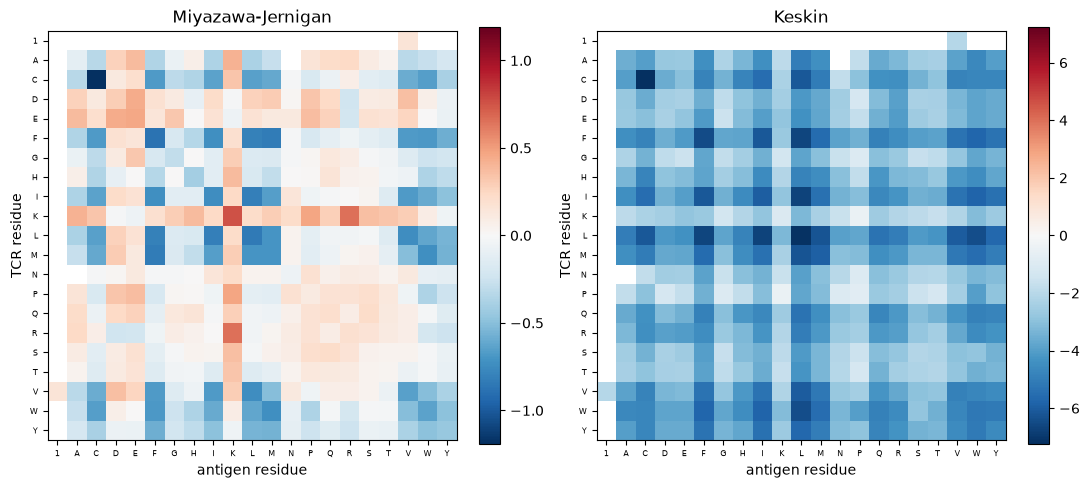

In [4]:
# Reference potentials: Miyazawa-Jernigan and Keskin
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pot, name in zip(axes, [mj(), keskin()], ['Miyazawa-Jernigan', 'Keskin']):
    im = plot_potential(ax, pot, name)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

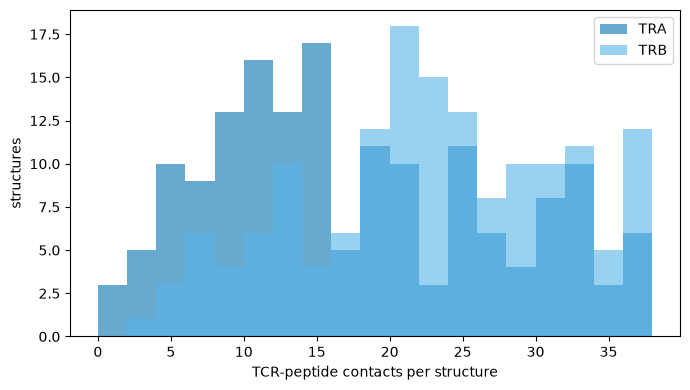

In [5]:
# Distribution of TCR-peptide contacts per structure (TRA vs TRB)
cps = an.contacts_per_structure(df)
fig, ax = plt.subplots(figsize=(7, 4))
for chain, color in [('TRA', '#0072B2'), ('TRB', '#56B4E9')]:
    vals = cps.filter(pl.col('chain.type.from') == chain)['n_contacts'].to_list()
    ax.hist(vals, bins=range(0, 40, 2), alpha=0.6, label=chain, color=color)
ax.set_xlabel('TCR-peptide contacts per structure'); ax.set_ylabel('structures'); ax.legend(); plt.tight_layout()

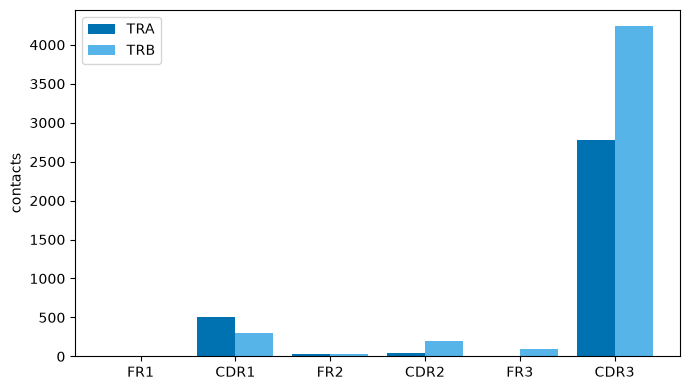

In [6]:
# Contacts by TCR region and chain (CDR3 dominates; TRB > TRA)
reg = an.region_contact_counts(df)
order = ['FR1', 'CDR1', 'FR2', 'CDR2', 'FR3', 'CDR3']
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(order)); w = 0.4
for k, (chain, color) in enumerate([('TRA', '#0072B2'), ('TRB', '#56B4E9')]):
    d = {r['region.type.from']: r['n_contacts'] for r in reg.filter(pl.col('chain.type.from')==chain).iter_rows(named=True)}
    ax.bar(x + (k-0.5)*w, [d.get(r, 0) for r in order], w, label=chain, color=color)
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel('contacts'); ax.legend(); plt.tight_layout()

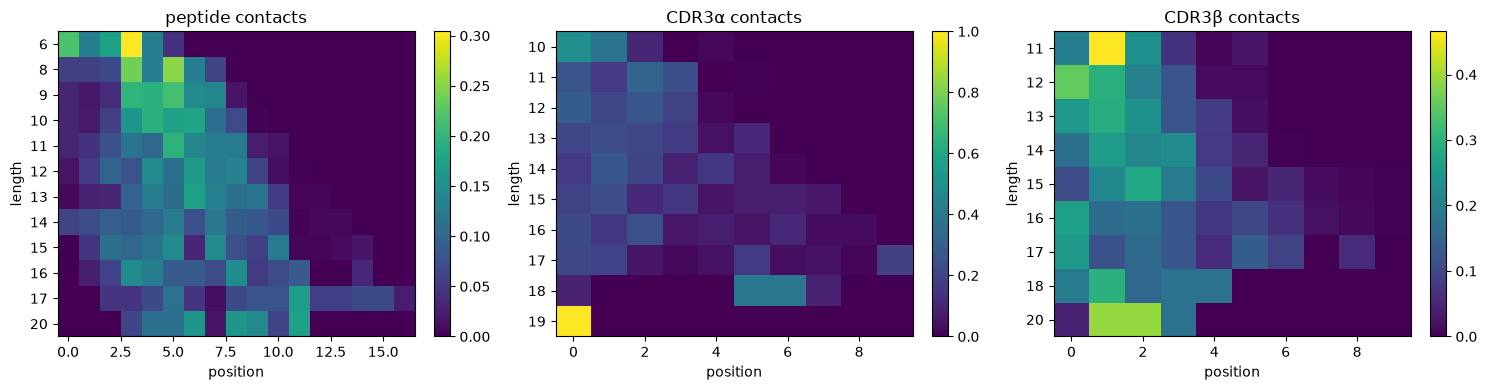

In [7]:
# Contact distribution over position, stratified by length: peptide, CDR3a, CDR3b
def plot_position_heatmap(ax, dist, title):
    lengths = sorted(dist['length'].unique().to_list())
    maxpos = dist['position'].max() + 1
    M = np.zeros((len(lengths), int(maxpos)))
    li = {L: i for i, L in enumerate(lengths)}
    for r in dist.iter_rows(named=True): M[li[r['length']], int(r['position'])] = r['n_contacts']
    M = M / M.sum(axis=1, keepdims=True).clip(min=1)  # row-normalise to a per-length profile
    im = ax.imshow(M, aspect='auto', cmap='viridis')
    ax.set_yticks(range(len(lengths))); ax.set_yticklabels(lengths)
    ax.set_xlabel('position'); ax.set_ylabel('length'); ax.set_title(title); return im

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, side, title in zip(axes, ['peptide', 'cdr3a', 'cdr3b'],
                           ['peptide', 'CDR3α', 'CDR3β']):
    im = plot_position_heatmap(ax, an.position_distribution(df, side), f'{title} contacts')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()